In [28]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import math


def plot_samples(data,
                 n=5,
                 max_cols=5,
                 cmap="tab20"
                 ):
    n = min(len(data), n)
    if n < max_cols:
        rows = 1
        cols = n
    else:
        rows = math.ceil(n / max_cols)
        cols = max_cols
    print(f"rows: {rows}, cols: {cols}")
    fig, ax = plt.subplots(nrows=rows, ncols=cols, sharex=True, sharey=True, figsize=(20, 10))
    #ax = ax.flatten()
    index = 0
    for i in range(rows):
        for j in range(cols):
            img = data[index]
            index += 1
            #    .numpy().reshape(X.shape[1],X.shape[2],2)
            print()
            ax[i, j].imshow(img, cmap=cmap, interpolation='nearest')
            if index >= n:
                break

    #ax[0].set_xticks([])
    #ax[0].set_yticks([])
    plt.tight_layout()
    # plt.savefig('./figures/mnist_all.png', dpi=300)
    plt.show()

In [2]:
(mnist_images, mnist_labels), (mnist_images_test, mnist_labels_test) = keras.datasets.mnist.load_data()
print(mnist_images.shape)
print(mnist_images_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [7]:
mnist_images[0, :2, 4:8]

array([[0, 0, 0, 0],
       [0, 0, 0, 0]], dtype=uint8)

In [3]:
X_train = tf.cast(mnist_images / 255, tf.float32)
y_train = tf.cast(mnist_labels, tf.int64)
y_train

2026-04-21 10:35:02.401437: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Max
2026-04-21 10:35:02.401467: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 64.00 GB
2026-04-21 10:35:02.401474: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 25.92 GB
I0000 00:00:1776760502.401490 15402592 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1776760502.401508 15402592 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


<tf.Tensor: shape=(60000,), dtype=int64, numpy=array([5, 0, 4, ..., 5, 6, 8])>

In [10]:
X_train[0, :, 4]

<tf.Tensor: shape=(28,), dtype=float32, numpy=
array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.21568628, 0.53333336,
       0.        , 0.        , 0.        ], dtype=float32)>

In [4]:
X_test = tf.cast(mnist_images_test / 255, tf.float32)
y_test = tf.cast(mnist_labels_test, tf.int64)

rows: 4, cols: 5






















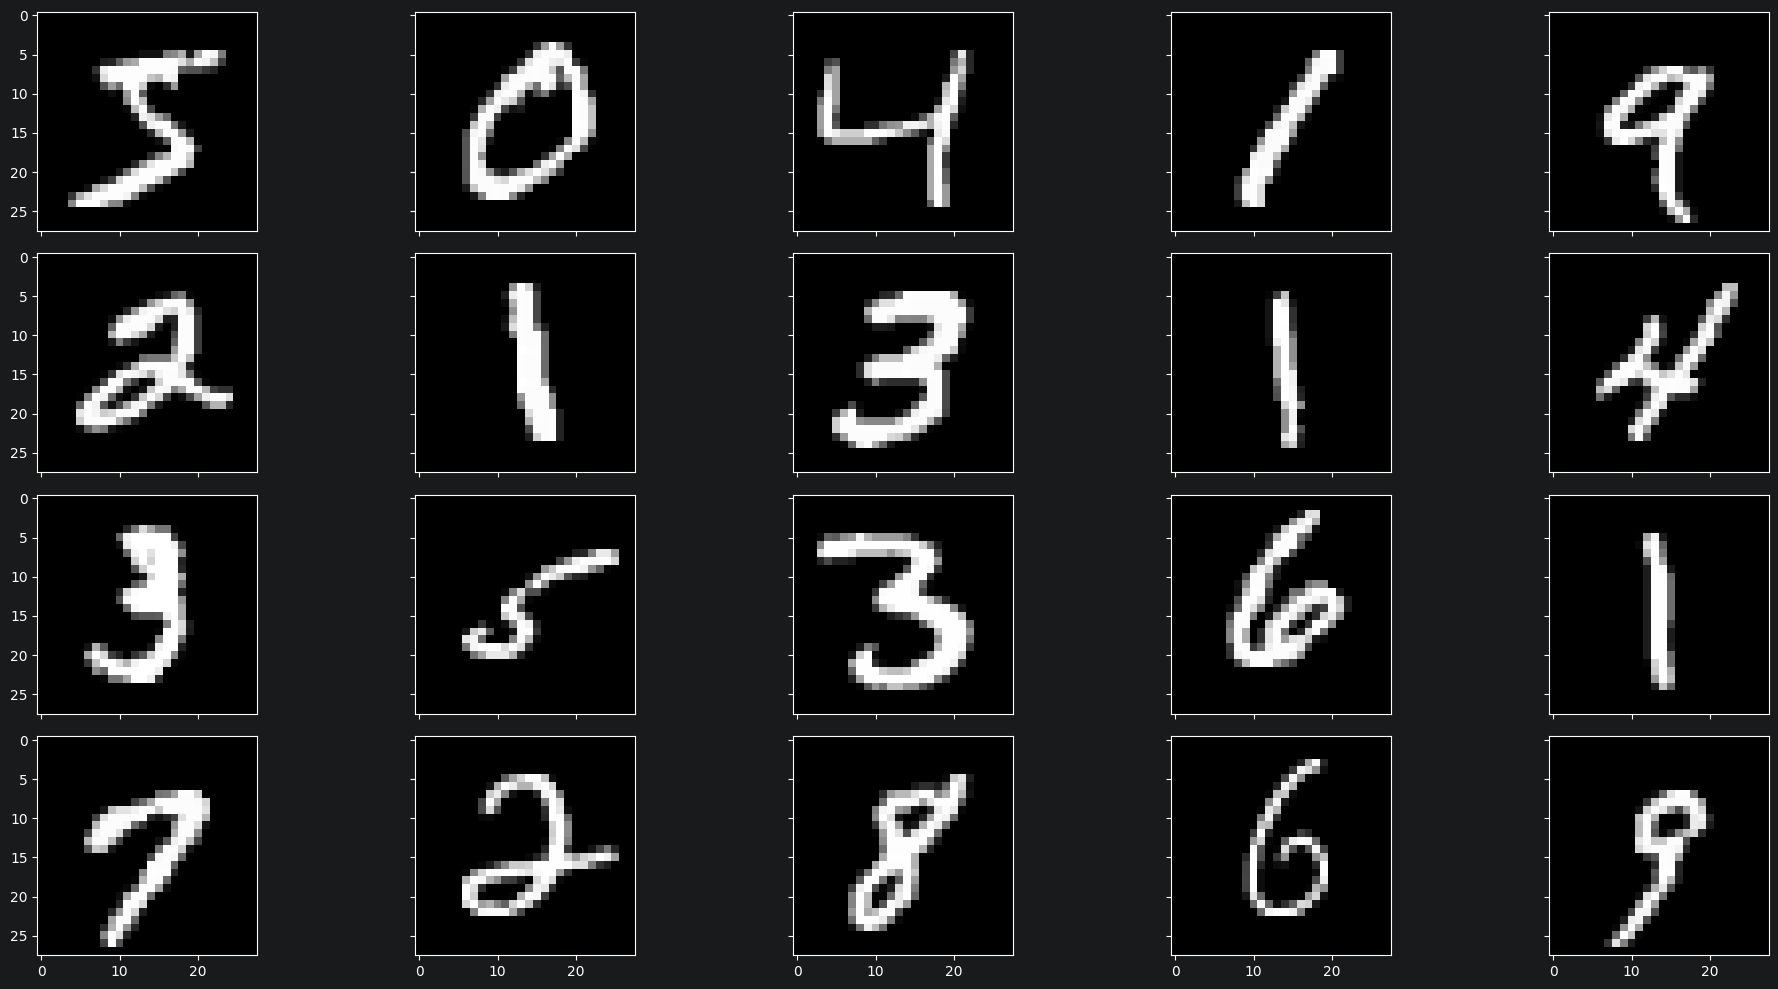

In [5]:
plot_samples(X_train, n=20, cmap="grey")

In [6]:
model = keras.models.Sequential(
        [
                keras.layers.Input(shape=[28, 28]),
                keras.layers.Flatten(),
                keras.layers.Dense(64, activation="relu", name="dense_0"),
                keras.layers.Dense(20, activation="relu", name="dense_1"),
                keras.layers.Dense(10, activation="softmax")
                ]
        )
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_0 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         1,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,750 (202.15 KB)

 Trainable params: 51,750 (202.15 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.fit(X_train, y_train, epochs=5, batch_size=64, validation_data=(X_test, y_test), verbose=1)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8389 - loss: 1.1848 - val_accuracy: 0.8477 - val_loss: 1.0340
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8287 - loss: 1.5239 - val_accuracy: 0.8370 - val_loss: 1.4327
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8296 - loss: 1.6780 - val_accuracy: 0.8146 - val_loss: 1.9960
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8229 - loss: 2.0811 - val_accuracy: 0.7959 - val_loss: 2.1672
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8275 - loss: 2.2708 - val_accuracy: 0.8029 - val_loss: 2.4281


In [15]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8672 - loss: 0.7872


[0.787161648273468, 0.8672000169754028]

In [7]:
x_1 = X_test[0, :, :]
print(x_1.shape)
x_1 = tf.reshape(x_1, (1, 28, 28))
print(x_1.shape)
y_pred = model(x_1)
print(y_pred)

(28, 28)
(1, 28, 28)
tf.Tensor(
[[0.11926427 0.06188343 0.19226478 0.08003426 0.06869579 0.07557599
  0.09410042 0.07346453 0.13735993 0.09735662]], shape=(1, 10), dtype=float32)


In [18]:
x_2 = X_test[:5, :, :]
print(x_2.shape)
y_pred = model.predict(x_2)
print(y_pred.shape)
# y_pred

(5, 28, 28)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
(5, 10)


# Vorhersage der Klasse mit der höchsten Wahrscheinlichkeit, aber nur wenn die Wahrscheinlichkeit über einem bestimmten Schwellenwert liegt

In [16]:
def predict(model, image, threshold):
    img = tf.reshape(image, (1, 28, 28))
    y_pred = model(img)
    y_proba = y_pred[0, :]
    print(y_proba.shape)
    i = tf.argmax(y_proba)
    print(f"Predicted class: {i}, probability: {y_proba[i]:0.2f}")
    result = None if y_proba[i] < threshold else i
    return result
    # y_pred = tf.squeeze(y_pred)


result = predict(model, X_train[21, :, :], threshold=0.5)
print(f"Predicted class: {result}")

(10,)
Predicted class: 2, probability: 0.11
Predicted class: None


In [38]:
threshold = 0.7
images = X_test[:15, :, :]
y_pred = model.predict(images)
print(y_pred.shape)
y_index = tf.argmax(y_pred, axis=1)
print(y_index.shape)
[y_index[i].numpy() if y_pred[i, y_index[i]] > threshold else None for i in range(len(images))]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
(15, 10)
(15,)


[np.int64(7),
 None,
 np.int64(1),
 np.int64(0),
 np.int64(4),
 np.int64(1),
 np.int64(4),
 np.int64(9),
 np.int64(6),
 np.int64(9),
 np.int64(0),
 np.int64(6),
 np.int64(9),
 np.int64(0),
 np.int64(1)]

In [27]:
threshold = 0.7
images = X_test[:15, :, :]


def predict_2(model, images, threshold=0.9):
    y_pred = model.predict(images)
    y_index = tf.argmax(y_pred, axis=1)
    return [y_index[i].numpy() if y_pred[i, y_index[i]] >= threshold else None for i in range(len(images))]


predict_2(model, X_train[:20, :, :], threshold=0.7)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


[None,
 np.int64(0),
 np.int64(4),
 np.int64(1),
 np.int64(9),
 np.int64(2),
 np.int64(1),
 np.int64(3),
 np.int64(1),
 np.int64(4),
 np.int64(3),
 np.int64(5),
 np.int64(3),
 np.int64(6),
 np.int64(1),
 np.int64(7),
 np.int64(2),
 np.int64(8),
 None,
 np.int64(9)]

In [6]:
dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
for x, y in dataset.take(5):
    print(f"x: {x.shape}, y: {y}")

x: (28, 28), y: 5
x: (28, 28), y: 0
x: (28, 28), y: 4
x: (28, 28), y: 1
x: (28, 28), y: 9


2026-04-21 10:35:24.037018: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [7]:
ds = dataset.shuffle(1000).batch(64).prefetch(buffer_size=tf.data.AUTOTUNE)
for x, y in ds.take(1):
    print(f"x: {x.shape}, y: {y}")

x: (64, 28, 28), y: [7 4 9 0 2 7 2 3 2 5 9 3 1 7 2 9 5 9 3 2 1 6 4 9 1 0 3 7 9 7 8 6 6 1 1 0 7
 5 1 4 3 6 5 9 8 4 3 6 5 5 0 2 9 0 1 4 5 6 6 2 3 6 7 7]


2026-04-21 10:35:26.595042: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [18]:
model = keras.models.Sequential(
        [
                keras.layers.Input(shape=[28, 28]),
                keras.layers.Flatten(),
                keras.layers.Dense(100, activation="relu", name="dense_000"),
                keras.layers.Dense(10, activation="softmax")
                ]
        )
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_000 (Dense)               │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.fit(ds, epochs=5, verbose=1)

Epoch 1/5


2026-04-21 10:35:50.820688: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8784 - loss: 0.4262
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9013 - loss: 0.3643
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8816 - loss: 0.4914
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8565 - loss: 0.7613
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8401 - loss: 1.0737


In [16]:
early_stopping_loss = tf.keras.callbacks.EarlyStopping(
        monitor='loss', patience=3, min_delta=0.005,
        restore_best_weights=True
        )
model.fit(ds, epochs=100, verbose=1, callbacks=[early_stopping_loss])


Epoch 1/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8913 - loss: 0.3838
Epoch 2/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9173 - loss: 0.2978
Epoch 3/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9201 - loss: 0.2899
Epoch 4/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9200 - loss: 0.2882
Epoch 5/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9213 - loss: 0.2891
Epoch 6/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9194 - loss: 0.2922


In [17]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9160 - loss: 0.3070


[0.3070477247238159, 0.9160000085830688]

In [19]:
early_stopping_val_loss = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        min_delta=0.01,
        restore_best_weights=True
        )
model.fit(
        X_train,
        y_train,
        batch_size=64,
        epochs=100,
        verbose=1,
        validation_split=0.1,
        callbacks=[early_stopping_val_loss]
        )


Epoch 1/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8866 - loss: 0.3991 - val_accuracy: 0.9295 - val_loss: 0.2501
Epoch 2/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9150 - loss: 0.3025 - val_accuracy: 0.9313 - val_loss: 0.2401
Epoch 3/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9165 - loss: 0.2972 - val_accuracy: 0.9312 - val_loss: 0.2529
Epoch 4/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9179 - loss: 0.2951 - val_accuracy: 0.9307 - val_loss: 0.2472


In [20]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9150 - loss: 0.2936


[0.29359984397888184, 0.9150000214576721]

In [22]:
y_train_oh = tf.one_hot(y_train, depth=10)
y_train_oh.shape

TensorShape([60000, 10])

In [23]:
ds_oh = dataset.map(lambda x, y: (x, tf.one_hot(y, depth=10)))
for x, y in ds_oh.take(1):
    print(f"x: {x.shape}, y: {y.shape}")

x: (28, 28), y: (10,)


In [26]:
ds_mnist = tf.data.Dataset.from_tensor_slices((mnist_images, mnist_labels))
ds_mnist = ds_mnist.map(lambda x, y: (tf.cast(x, tf.float32) / 255, tf.cast(y, tf.int64)))
for x, y in ds_mnist.take(1):
    print(f"x: {x.shape}, y: {y}")

x: (28, 28), y: 5
